In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi
from skimage.segmentation import find_boundaries
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import seaborn as sns
from scipy.ndimage import maximum_filter, label
from scipy.stats import skewnorm
from scipy.stats import lognorm

In [2]:
#Defining all the required functions

#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Defining constants
dx = 0.0625
dy = 0.0625

def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

In [3]:
#Denoising the data
def gaussian_fft_filter_2d(J_squared, k0):
    """
    Apply a Gaussian low-pass filter in Fourier space to a 2D field.

    Parameters
    ----------
    J_squared : 2D numpy array
        Input real-space data
    k0 : float
        Filter width in k-space (grid units). Smaller = stronger smoothing.

    Returns
    -------
    J_filtered : 2D numpy array
        Smoothed real-space data
    """

    # FFT
    F = np.fft.fft2(J_squared)
    F_shifted = np.fft.fftshift(F)

    # k-grid
    nx, ny = J_squared.shape
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2

    # Gaussian filter in k-space
    gaussian = np.exp(-K2 / (2 * k0**2))

    # Apply filter
    F_filt = F_shifted * gaussian

    # Inverse FFT
    F_filt = np.fft.ifftshift(F_filt)
    J_filtered = np.fft.ifft2(F_filt)

    # Return real part
    return np.real(J_filtered)

In [4]:
betas = [0.0625, 1, 16]

spectra = {}

for beta in betas:

    base = f"/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_{beta}/beta_e_1"

    File_Bx = f"{base}/Bx_ApJ_t200.h5"
    File_By = f"{base}/By_ApJ_t200.h5"
    File_Bz = f"{base}/Bz_ApJ_t200.h5"

    with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T
        data_Bz = fBz['DS1'][:].T

    # Current components
    data_Jx = partial_y_fft(data_Bz, dx)
    data_Jy = -partial_x_fft(data_Bz, dy)
    data_Jz = partial_x_fft(data_By, dy) - partial_y_fft(data_Bx, dx)

    Jpar = (data_Jx*data_Bx + data_Jy*data_By + data_Jz*data_Bz) / \
           np.sqrt(data_Bx**2 + data_By**2 + data_Bz**2)

    # Spectra
    spectrum_Jpar = compute_radial_spectrum(Jpar, dx, dy)
    # spectrum_Jx = compute_radial_spectrum(data_Jx, dx, dy)
    # spectrum_Jy = compute_radial_spectrum(data_Jy, dx, dy)
    # spectrum_Jz = compute_radial_spectrum(data_Jz, dx, dy)

    # spectrum_J = np.copy(spectrum_Jz)
    # spectrum_J['sp'] = spectrum_Jx['sp'] + spectrum_Jy['sp'] + spectrum_Jz['sp']

    # spectrum_Jperp = np.copy(spectrum_Jz)
    # spectrum_Jperp['sp'] = spectrum_J['sp'] - spectrum_Jpar['sp']

    spectra[beta] = spectrum_Jpar

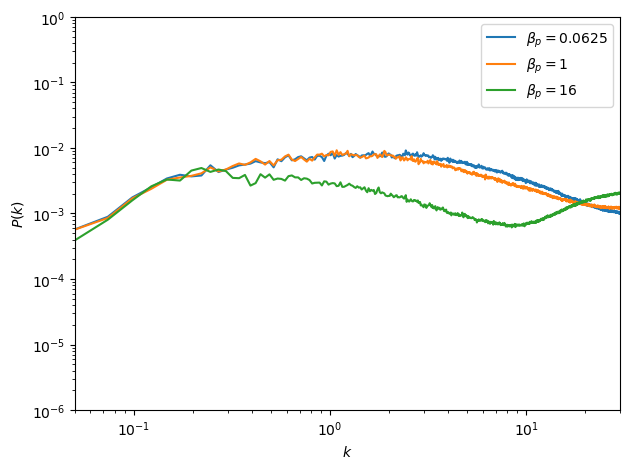

In [5]:
plt.figure()

for beta in betas:
    spec = spectra[beta]

    plt.loglog(
        spec['kk'],
        spec['sp'],
        label=fr"$\beta_p = {beta}$"
    )

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.xlim(5e-2, 30)
plt.ylim(1e-6, 1)

plt.legend()
plt.tight_layout()

plt.savefig("Jpar_Spectrum_beta_scan_t200.png", dpi=300)
plt.show()